# Notebook 3: HardwareStation and Advanced Scenarios

In the previous notebook, we used `Parser`, `MultibodyPlant`, `SceneGraph`, and `DiagramBuilder` to build robot simulations in Drake. Now, we'll see how the `HardwareStation` system and a `scenario.yaml` file can simplify this process for many scenarios.

**Learning Objectives:**
1. Understand `HardwareStation`: a `System` that provides a convenient, high-level interface for setting up and simulating common robot hardware (like arms, grippers, and cameras) using a simple configuration.
2. Get experience with `scenario.yaml` files for declarative scene setup
3. Compare the "manual" approach with using `HardwareStation`

**What you'll build:** A custom manipulation scene using `HardwareStation` and scenario files, featuring your initials from Notebook 2!

**Reference:** In this notebook, we will be building on examples from [Chapter 2.5](https://manipulation.csail.mit.edu/robot.html#hardware_station) in the Manipulation Textbook. This chapter contains a good description of what `HardwareStation` is and how you can use it. Make sure to read this chapter before starting the exercises below!

---


## Setup and Imports

Let's import the Drake functionality we'll need for HardwareStation and scenario files.

To build the entire scene we only need to import two functions (that we will explain more soon):
- `MakeHardwareStation`
- `LoadScenario`

(Notice that these two functions, as well as other functionality for `HardwareStation`, lives in the `manipulation` package that is made specifically for this class, not in Drake!)

In [1]:
from pathlib import Path

import numpy as np
from pydrake.all import (
    Diagram,
    DiagramBuilder,
    RigidTransform,
    Simulator,
    StartMeshcat,
)

from manipulation.exercises.grader import Grader
from manipulation.exercises.intro.test_hardwarestation_and_scenarios import (
    TestHardwareStationBasic,
    TestHardwareStationBimanual,
    TestHardwareStationFullSystem,
)
from manipulation.letter_generation import create_sdf_asset_from_letter
from manipulation.station import (
    LoadScenario,
    MakeHardwareStation,
    RobotDiagram,
)
from manipulation.utils import RenderDiagram, running_as_notebook

## Meshcat Visualization

As always, let's start Meshcat for our 3D visualization!


In [2]:
# Start meshcat for visualization
meshcat = StartMeshcat()
print("Click the link above to open Meshcat in your browser!")

INFO:drake:Meshcat listening for connections at http://localhost:7000


Click the link above to open Meshcat in your browser!


---

## Part 1: From Manual Setup to HardwareStation

In Notebook 2, you manually created a simulation by:
1. Creating `DiagramBuilder`, `MultibodyPlant`, `SceneGraph`
2. Adding `Parser`, loading robots, welding frames
3. Adding visualization, finalizing, building...

The function `MakeHardwareStation` does all of this for you automatically! Let's see the difference.

**YOUR TASK:** Let's start by creating a simple simulation with just the passive IIWA14 as in the last notebook, but using `HardwareStation` instead of manual setup.

**Key Concepts:**
- Specify the scene with scenario directives (in YAML format)
- Call `LoadScenario` to parse the YAML string into a `scenario` object
- Call `MakeHardwareStation` with the `scenario` to set up the entire scene

**Reference:** To understand how to write scenario directives and use the functions above, we recommend looking at the [Bimanual Manipulation Example](https://deepnote.com/workspace/Manipulation-ac8201a1-470a-4c77-afd0-2cc45bc229ff/project/8f86172b-b597-4ceb-9bad-92d11ac7a6cc/notebook/bimanual-3df3abe2b1b949eb9daaf3748b16a218) before you start.


In [3]:
# TODO: Create a simple IIWA14 simulation using HardwareStation


from manipulation.station import LoadScenario, MakeHardwareStation
from pydrake.all import DiagramBuilder


def create_IIWA14_with_hardware_station() -> Diagram:
    # TODO: Write a simple scenario string for loading the IIWA14 robot.

    #       Remember to weld the robot to the world frame!
    # HINT: Look at the Bimanual Manipulation Example in the reference above.
    #       In particular, look at the `directives` section, which adds two
    #       IIWA7 robots to the scene. Here are some tips:
    #       - You can pick `name` to be anything you want.
    #       - The example uses the IIWA7, but you can use the IIWA14 from earlier.
    #       - The example adds a `wsg` gripper to the robot, feel free to do the same!
    #       - Under `model_drivers` the example specifies controllers for the robot.
    #         We haven't learned about this yet, so feel free to ignore it for now.
    # TODO: Add the IIWA14 robot model

    # TODO: Set default joint positions
    # HINT: The names for the joints that are used in the `default_joint_positions` come
    #       from the URDF/SDF file. In this case, have a look at the
    #       `iiwa14_primitive_collision.urdf` file:
    #       https://github.com/RobotLocomotion/models/blob/master/iiwa_description/urdf/iiwa14_primitive_collision.urdf
    # TODO: Weld the robot base to the world frame
    scenario_string = """
    directives:
      - add_model:
          name: iiwa
          file: "package://drake_models/iiwa_description/urdf/iiwa14_primitive_collision.urdf"
          default_joint_positions:
            iiwa_joint_1: [0.0]
            iiwa_joint_2: [0.1]
            iiwa_joint_3: [0.0]
            iiwa_joint_4: [-1.2]
            iiwa_joint_5: [0.0]
            iiwa_joint_6: [1.6]
            iiwa_joint_7: [0.0]
      - add_weld:
          parent: world
          child: iiwa::base
    model_drivers:
        iiwa: !IiwaDriver {}
    """
    # TODO: Load the scenario directly from the string using the `LoadScenario` function
    scenerio = LoadScenario(data=scenario_string)

    # TODO: Create HardwareStation with this scenario and meshcat,
    #       using the `MakeHardwareStation` function
    meshcat = StartMeshcat()
    # TODO: Create a DiagramBuilder, add the station to it, and build the diagram
    builder = DiagramBuilder()
    station = builder.AddSystem(MakeHardwareStation(scenerio, meshcat))
    diagram = builder.Build()
    # TODO: Return the diagram built by DiagramBuilder

    return diagram

In [4]:
# Use this to test your implementation if you want!
Grader.grade_output([TestHardwareStationBasic], [locals()], "results.json")
Grader.print_test_results("results.json")

INFO:drake:Meshcat listening for connections at http://localhost:7001


Total score is 10/10.

Score for Test basic IIWA14 HardwareStation creation and structure is 10/10.


Let us look at the block diagram for the system:

INFO:drake:Meshcat listening for connections at http://localhost:7002


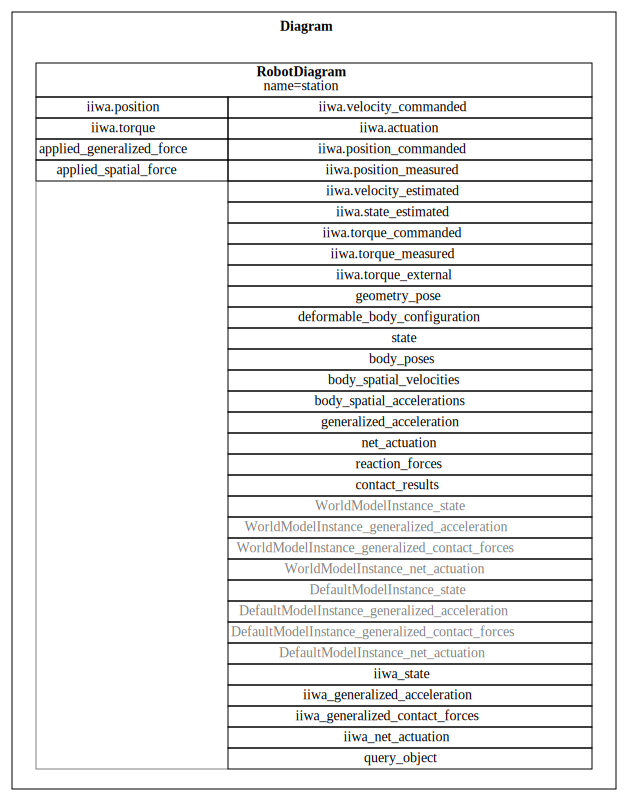

In [5]:
diagram = create_IIWA14_with_hardware_station()
RenderDiagram(diagram, max_depth=1)

In [9]:
from pydrake.systems.analysis import Simulator
import numpy as np

# 1. Create the diagram and context
diagram = create_IIWA14_with_hardware_station()
context = diagram.CreateDefaultContext()

# 2. Access the station to fix the ports
station = diagram.GetSubsystemByName("station")
station_context = station.GetMyMutableContextFromRoot(context)

# Fix the Position Port (7 joints)
q_home = np.zeros(7)
station.GetInputPort("iiwa.position").FixValue(station_context, q_home)

# Fix the Feed-forward Torque Port (7 joints)
# This is likely the "u1" port that caused your error. 
# Providing zeros means "no extra torque".
t_zero = np.zeros(7)
station.GetInputPort("iiwa.torque").FixValue(station_context, t_zero)

# 3. Setup Simulator
simulator = Simulator(diagram, context)
simulator.set_target_realtime_rate(1.0)

print(f"Simulation starting. Check Meshcat!")
simulator.AdvanceTo(15.0)

INFO:drake:Meshcat listening for connections at http://localhost:7004


Simulation starting. Check Meshcat!


---

## Part 2: Bimanual IIWA setup

Great! To highlight how easy it is to modify a scene using scenario directives, let's add another IIWA14 to the scene.

**YOUR TASK:** Create a new scenario with two IIWA14 robots, each welded to the world at different positions.


**Key concept:** Scenario files make it simple and flexible to modify your scene—adding robots, changing positions, or updating configurations can be done with just a few lines.


**Reference:** To understand how to write scenario directives and use the functions above, we recommend looking at the [Bimanual Manipulation Example](https://deepnote.com/workspace/Manipulation-ac8201a1-470a-4c77-afd0-2cc45bc229ff/project/8f86172b-b597-4ceb-9bad-92d11ac7a6cc/notebook/bimanual-3df3abe2b1b949eb9daaf3748b16a218).


In [13]:
import textwrap

def create_bimanual_IIWA14_with_hardware_station() -> Diagram:
    # TODO: Write a simple scenario string for loading the two IIWA14 robots.
    # TODO: Remember to weld the robots to the world frame at different positions!

    # TODO: Add the IIWA14 robot model for the left arm
    # TODO: Set default joint positions
    # TODO: Weld the robot base to the world frame
    # TODO: Add the IIWA14 robot model for the right arm
    # TODO: Set default joint positions
    # TODO: Weld the robot base to the world frame
    scenario_data = textwrap.dedent("""
        directives:
        - add_model:
            name: iiwa_left
            file: package://drake_models/iiwa_description/urdf/iiwa14_primitive_collision.urdf
            default_joint_positions:
                iiwa_joint_1: [-1.57]
                iiwa_joint_2: [0.1]
                iiwa_joint_3: [0]
                iiwa_joint_4: [-1.2]
                iiwa_joint_5: [0]
                iiwa_joint_6: [1.6]
                iiwa_joint_7: [0]
        - add_weld:
            parent: world
            child: iiwa_left::base
        - add_model:
            name: wsg_left
            file: package://drake_models/wsg_50_description/sdf/schunk_wsg_50_with_tip.sdf
        - add_weld:
            parent: iiwa_left::iiwa_link_7
            child: wsg_left::body
            X_PC:
                translation: [0, 0, 0.09]
                rotation: !Rpy { deg: [90, 0, 90]}
        - add_model:
            name: iiwa_right
            file: package://drake_models/iiwa_description/urdf/iiwa14_primitive_collision.urdf
            default_joint_positions:
                iiwa_joint_1: [1.57]
                iiwa_joint_2: [0.1]
                iiwa_joint_3: [0]
                iiwa_joint_4: [-1.2]
                iiwa_joint_5: [0]
                iiwa_joint_6: [1.6]
                iiwa_joint_7: [0]
        - add_weld:
            parent: world
            child: iiwa_right::base
            X_PC:
                translation: [0.6, 0, 0]
        - add_model:
            name: wsg_right
            file: package://drake_models/wsg_50_description/sdf/schunk_wsg_50_with_tip.sdf
        - add_weld:
            parent: iiwa_right::iiwa_link_7
            child: wsg_right::body
            X_PC:
                translation: [0, 0, 0.09]
                rotation: !Rpy { deg: [90, 0, 90]}
        model_drivers:
            iiwa_left: !IiwaDriver
                control_mode: position_only
                hand_model_name: wsg_left
            wsg_left: !SchunkWsgDriver {}
            iiwa_right: !IiwaDriver
                control_mode: position_only
                hand_model_name: wsg_right
            wsg_right: !SchunkWsgDriver {}
    """)


    # TODO: Load the scenario directly from the string
    scenario = LoadScenario(data=scenario_data)
    # TODO: Create HardwareStation with this scenario and meshcat

    # TODO: Make a DiagramBuilder, add the station to it, build the diagram
    meshcat = StartMeshcat()
    builder = DiagramBuilder()
    station = builder.AddSystem(MakeHardwareStation(scenario, meshcat))
    diagram = builder.Build()
    # TODO: Return the diagram
    return diagram  # Remove this when you have implemented the function


diagram = create_bimanual_IIWA14_with_hardware_station()

INFO:drake:Meshcat listening for connections at http://localhost:7005


In [14]:
# Use this to test your implementation if you want!
Grader.grade_output([TestHardwareStationBimanual], [locals()], "results.json")
Grader.print_test_results("results.json")

INFO:drake:Meshcat listening for connections at http://localhost:7006


Total score is 10/10.

Score for Test bimanual IIWA14 HardwareStation creation and structure is 10/10.


Next, let us simulate the setup to make sure it works as expected:

In [20]:
print(f"Check your Meshcat window ({meshcat.web_url()}) to see the robot simulation!")

# Let us also simulate the simple IIWA14 setup to make sure it works as expected!
# TODO: Create a context for the station
diagram = create_bimanual_IIWA14_with_hardware_station()
context = diagram.CreateDefaultContext()


station = diagram.GetSubsystemByName("station")
station_context = station.GetMyMutableContextFromRoot(context)

q_left = np.array([-1.57, 0.1, 0, -1.2, 0, 1.6, 0])
q_right = np.array([1.57, -0.1, 0, 1.2, 0, -1.6, 0])

station.GetInputPort("iiwa_left.position").FixValue(station_context, q_left)
station.GetInputPort("iiwa_right.position").FixValue(station_context, q_right)

station.GetInputPort("wsg_left.position").FixValue(station_context, [0.1])
station.GetInputPort("wsg_right.position").FixValue(station_context, [0.1])
# TODO: Create a simulator

simulator = Simulator(diagram, context)
# TODO: Set real-time rate to 1.0
simulator.set_target_realtime_rate(1.0)
# TODO: Run simulation for 15 seconds
simulator.AdvanceTo(15.0)

INFO:drake:Meshcat listening for connections at http://localhost:7001


Check your Meshcat window (http://localhost:7000) to see the robot simulation!


---

## Part 3: Custom Assets with Scenario Files and Model Directives

Now let's learn how to use scenario files to load your custom assets! We'll create scenario YAML files that can reference your custom models and load them into `HardwareStation`.

**YOUR TASK:** Create scenario files from scratch and load your custom assets using model directives.

**Goal:** Export a video of the simulation with the bimanual IIWA14 setup and your assets, and upload it to Gradescope.

**Reference:** To understand how to write scenario directives and use the functions above, we recommend looking at the [Bimanual Manipulation Example](https://deepnote.com/workspace/Manipulation-ac8201a1-470a-4c77-afd0-2cc45bc229ff/project/8f86172b-b597-4ceb-9bad-92d11ac7a6cc/notebook/bimanual-3df3abe2b1b949eb9daaf3748b16a218).


First, let us make sure that we have our letters generated in the right folder. Run the code below. Feel free to change the letter properties!

In [21]:
# Let us save our files to a new folder called `assets` in the `Files`
# section on the left
output_dir = Path("assets/")

# TODO: Insert your initials here!
your_initials = "BPG"

for letter in your_initials:
    create_sdf_asset_from_letter(
        text=letter,
        font_name="DejaVu Sans",
        letter_height_meters=0.2,
        extrusion_depth_meters=0.07,
        output_dir=output_dir / f"{letter}_model",
    )

In order to load assets using the model directives we need to have them as local files. Let us save our table asset from the previous notebook to a local file. Fill out the missing code below:

In [22]:
# TODO: Paste your table_sdf = ... code from Notebook 2 here
table_sdf = """<?xml version="1.0"?>
<sdf version="1.7">
    <model name="table">
    <pose>0 0 0.05 0 0 0</pose>
    <link name="table_link">
        <inertial>
        <mass>1.0</mass>
        <inertia>
            <ixx>0.334</ixx>
            <ixy>0.0</ixy>
            <ixz>0.0</ixz>
            <iyy>0.334</iyy>
            <iyz>0.0</iyz>
            <izz>0.667</izz>
        </inertia>
        </inertial>
        <collision name="table_collision">
        <geometry>
            <box>
            <size>2 2 0.1</size>
            </box>
        </geometry>
        </collision>
        <visual name="table_visual">
        <geometry>
            <box>
            <size>2 2 0.1</size>
            </box>
        </geometry>
        <material>
            <diffuse>0.5 0.35 0.2 1.0</diffuse>
        </material>
        </visual>
    </link>
    </model>
</sdf>
"""

# TODO: Write the table SDF to a file
table_sdf_path = "assets/table.sdf"
with open(table_sdf_path, "w") as f:
    f.write(table_sdf)

Great. Now we should be able to load our custom assets, similar to what we did before with the IIWA14 in the scenario directives. To access a local file in the scenario directives, use the following syntax:
- `file://absolute/path/to/your/file.sdf`

For example, for the letter `B` in the (relative) folder `assets` one could use the following f-string:
- `f"file://{Path.cwd()}/assets/B_model/B.sdf"`

**NOTE**: The asset path must be absolute, which is why we call `Path.cwd()` to get the current working directory above! The asset path is also sensitive to spaces and indentation. If you're unable to load your assets, make sure there are no double spaces anywhere!

We want to weld the table to the world so it doesn't fall down.

We also want to specify a default free-body pose for the initials, which you can do as follows (inside an f-string):
```
- add_model:
    name: {YOUR_OBJECT_NAME}
    file: {PATH_TO_OBJECT}
    default_free_body_pose:
        {BASE_LINK_NAME}:
            translation: [x_pos, y_pos, z_pos]
            rotation: !Rpy {{ deg: [x_rot, y_rot, z_rot] }}
```
Make sure to replace:
- `{YOUR_OBJECT_NAME}`: any name you prefer
- `{PATH_TO_OBJECT}`: the path to the `.sdf` or `.urdf` file (can be either a local file or the path in the `package` repo, like `drake-models`)
- `{BASE_LINK_NAME}`: the name of the base link in the `.sdf` or `.urdf` file.

For instance, for the letter `B`, you could do (within an f-string):

```
- add_model:
    name: B_letter
    file: file://{Path.cwd()/assets/B_model.sdf}
    default_free_body_pose:
        B_body_link:
            translation: [0, 1.0, 0.75]
            rotation: !Rpy {{ deg: [42, 33, 18] }}
```

In addition, we want to load an object from [drake-models](https://github.com/RobotLocomotion/models), 
also specified as a free-floating body (for instance one of [these objects](https://github.com/RobotLocomotion/models/tree/master/ycb))

**To summarize, here is everything you need to do for the scene you should create below:**
- Load two Kuka IIWA14 robots with default joint positions, welded to the world frame
- Load the table from the local `.sdf` file, welded to the world frame
- Load your letter initials from the local `.sdf` files, with default free-body poses 
- Load one or more objects from [drake-models](https://github.com/RobotLocomotion/models) into your scene, with default free-body poses

In [29]:
import os
import textwrap
from pathlib import Path
import numpy as np
from manipulation.station import LoadScenario, MakeHardwareStation
from pydrake.all import DiagramBuilder, StartMeshcat, Diagram

def create_bimanual_IIWA14_with_table_and_initials_and_assets():
    # Pobieramy ścieżkę roboczą, aby stworzyć ścieżki absolutne
    cwd = Path.cwd()
    
    # Definiujemy ścieżki do plików SDF
    table_path = f"file://{cwd}/assets/table.sdf"
    b_model_path = f"file://{cwd}/assets/B_model/B.sdf"
    # Przykład obiektu z biblioteki drake_models (np. puszka zupy z zestawu YCB)
    soup_can_path = "package://drake_models/ycb/sdf/003_cracker_box.sdf"

    # Używamy f-stringa z podwójnymi klamrami dla YAMLowych słowników
    scenario_string = f"""
    directives:
      # LEWE RAMIĘ
      - add_model:
          name: iiwa_left
          file: "package://drake_models/iiwa_description/urdf/iiwa14_primitive_collision.urdf"
          default_joint_positions:
            iiwa_joint_1: [-1.57]
            iiwa_joint_4: [-1.2]
            iiwa_joint_6: [1.6]
      - add_weld:
          parent: world
          child: iiwa_left::base
          X_PC:
            translation: [0, -0.5, 0]

      # PRAWE RAMIĘ
      - add_model:
          name: iiwa_right
          file: "package://drake_models/iiwa_description/urdf/iiwa14_primitive_collision.urdf"
          default_joint_positions:
            iiwa_joint_1: [1.57]
            iiwa_joint_4: [-1.2]
            iiwa_joint_6: [1.6]
      - add_weld:
          parent: world
          child: iiwa_right::base
          X_PC:
            translation: [0, 0.5, 0]

      # STÓŁ - Przyspawany do świata
      - add_model:
          name: table
          file: "{table_path}"
      - add_weld:
          parent: world
          child: table::table_link
          X_PC:
            translation: [0.6, 0, 0]

      # LITERA B
      - add_model:
          name: letter_B
          file: "{b_model_path}"
          default_free_body_pose:
            B_body_link:  # Zmienione z base_link na B_body_link zgodnie z błędem
              translation: [0.6, 0.1, 0.8]
              rotation: !Rpy {{ deg: [0, 0, 90] }}

    model_drivers:
        iiwa_left: !IiwaDriver {{ control_mode: position_only }}
        iiwa_right: !IiwaDriver {{ control_mode: position_only }}
    """

    # Oczyszczamy string z wcięć i ładujemy scenariusz
    scenario = LoadScenario(data=textwrap.dedent(scenario_string))
    
    # Inicjalizacja wizualizacji i diagramu
    meshcat = StartMeshcat()
    builder = DiagramBuilder()
    
    # Tworzymy stację
    station = builder.AddSystem(MakeHardwareStation(scenario, meshcat))
    
    diagram = builder.Build()
    
    return diagram, station

# Uruchomienie
diagram, station = create_bimanual_IIWA14_with_table_and_initials_and_assets()
print("Scena załadowana z własnymi zasobami!")

INFO:drake:Meshcat listening for connections at http://localhost:7007


Scena załadowana z własnymi zasobami!


Let us visualize the block diagram:

INFO:drake:Meshcat listening for connections at http://localhost:7008


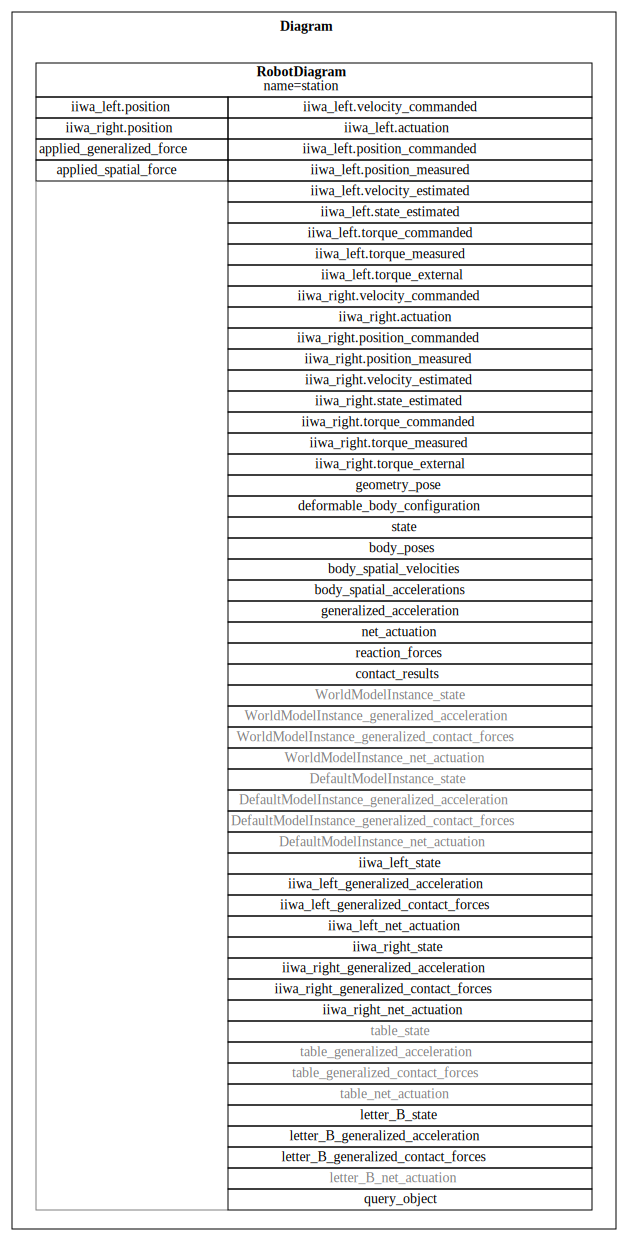

In [30]:
diagram, station = create_bimanual_IIWA14_with_table_and_initials_and_assets()
RenderDiagram(diagram, max_depth=1)

Let's run a quick simulation to see the HardwareStation in action:


In [31]:
from pydrake.all import Simulator, RigidTransform

def simulate_full_system(
    iiwa_left_q0: np.ndarray,
    iiwa_right_q0: np.ndarray,
    letter_poses: list[RigidTransform],
    object_poses: list[RigidTransform],
    simulation_time: float = 3.0,
    use_realtime: bool = True,
) -> None:
    # 1. Tworzymy diagram i stację
    diagram, station = create_bimanual_IIWA14_with_table_and_initials_and_assets()
    
    # 2. Tworzymy główny kontekst i pobieramy konteksty podsystemów
    context = diagram.CreateDefaultContext()
    station_context = station.GetMyMutableContextFromRoot(context)
    
    plant = station.GetSubsystemByName("plant")
    context_plant = plant.GetMyMutableContextFromRoot(context)

    # --- KONFIGURACJA ROBOTÓW ---

    # Ustawiamy wartości na portach wejściowych (to one sterują robotem w trybie position_only)
    station.GetInputPort("iiwa_left.position").FixValue(station_context, iiwa_left_q0)
    station.GetInputPort("iiwa_right.position").FixValue(station_context, iiwa_right_q0)

    # Opcjonalnie: Ustawiamy stan początkowy w Plant (aby roboty zaczęły fizycznie w tej pozycji)
    left_iiwa_model = plant.GetModelInstanceByName("iiwa_left")
    right_iiwa_model = plant.GetModelInstanceByName("iiwa_right")
    plant.SetPositions(context_plant, left_iiwa_model, iiwa_left_q0)
    plant.SetPositions(context_plant, right_iiwa_model, iiwa_right_q0)

    # --- KONFIGURACJA OBIEKTÓW (INITIALS) ---

    # Pobieramy instancję modelu litery B
    letter_b_model = plant.GetModelInstanceByName("letter_B")
    # Pobieramy ciało (RigidBody) - nazwa musi zgadzać się z SDF (B_body_link)
    letter_b_body = plant.GetBodyByName("B_body_link", letter_b_model)
    
    # Ustawiamy pozycję w przestrzeni 3D
    plant.SetFreeBodyPose(context_plant, letter_b_body, letter_poses[0])

    # Jeśli dodałeś cracker_box w scenariuszu, ustaw go również:
    # box_model = plant.GetModelInstanceByName("cracker_box")
    # box_body = plant.GetBodyByName("base_link_cracker_box", box_model)
    # plant.SetFreeBodyPose(context_plant, box_body, object_poses[0])

    # --- SYMULACJA ---

    # Tworzymy simulator
    simulator = Simulator(diagram, context)
    
    if use_realtime:
        simulator.set_target_realtime_rate(1.0)
    
    # Startujemy symulację
    print(f"Symulacja startuje na {simulation_time} sekund...")
    simulator.AdvanceTo(simulation_time)
    print("Symulacja zakończona.")

# Przykładowe wywołanie (musisz mieć zdefiniowane RigidTransform)
# from pydrake.all import RotationMatrix
# q0 = np.array([0, 0.1, 0, -1.2, 0, 1.6, 0])
# pose = RigidTransform(RotationMatrix.MakeZRotation(np.pi/2), [0.6, 0, 0.8])
# simulate_full_system(q0, q0, [pose], [pose])

In [33]:
# Test your simulation
print(f"Check your Meshcat window ({meshcat.web_url()}) to see the robot simulation!")
print("Running HardwareStation simulation...")

meshcat.StartRecording()
simulate_full_system(
    iiwa_left_q0=np.array([0, 0, 0, 0, 0, 0, 0]),
    iiwa_right_q0=np.array([0, 0, 0, 0, 0, 0, 0]),
    # NOTE: Here we have provided the initial poses for three letters, and one object, as
    # an example. Change these to match your setup!
    letter_poses=[
        # You can add rotations to the RigidTransform if you want, but we will learn more about that later!
        # The letters should be placed such that they are not in collision with each other, and such that
        # they fall onto the table.
        RigidTransform([0.7, 0.0, 1.0]),
        RigidTransform([0.9, 0.0, 1.0]),
        RigidTransform([1.1, 0.0, 1.0]),
    ],
    object_poses=[
        RigidTransform([0.5, 0.0, 0.75]),
    ],
    simulation_time=5.0 if running_as_notebook else 5.0,
    use_realtime=running_as_notebook,
)
meshcat.StopRecording()
meshcat.PublishRecording()

print("HardwareStation simulation completed!")

INFO:drake:Meshcat listening for connections at http://localhost:7007


Check your Meshcat window (http://localhost:7000) to see the robot simulation!
Running HardwareStation simulation...
Symulacja startuje na 5.0 sekund...
Symulacja zakończona.
HardwareStation simulation completed!


---

# Congratulations!

You've successfully completed the notebook on **HardwareStation and Advanced Scenarios**! You've learned:

- **HardwareStation** - A convenient high-level tool that automates complex robot setup
- **Scenario files** - Declarative YAML-based scene configuration  
- **Custom assets** - Loading your own models into scenarios  

---

# VERIFICATION IN GRADESCOPE
Congratulations! You are all done with this notebook. Now play the simulation back in your browser, and upload a screen recording of it in Gradescope.
